# 🫀 Notebook 02 – Tiền xử lý & Huấn luyện: TIM MẠCH
**Dataset:** `cardio_train.csv` (70,000 mẫu)  
**Sinh viên:** Lê Trung Hiếu – 102220187

---
### ⚠️ 6 vấn đề xử lý đặc thù
| # | Vấn đề | Xử lý |
|---|--------|-------|
| 1 | `age` tính bằng **ngày** (vd: 18393 days) | Chuyển sang **năm** |
| 2 | `ap_hi` max=16020, `ap_lo` max=11000 (lỗi nhập liệu) | Lọc theo range y khoa |
| 3 | `ap_hi < ap_lo` (1234 hàng – bất khả thi) | Drop những hàng này |
| 4 | `gender` mã hóa 1/2 thay vì 0/1 | Recode: 1→0 (Female), 2→1 (Male) |
| 5 | `cholesterol`, `gluc` ordinal 1–3 | Shift về 0–2 cho nhất quán |
| 6 | Cần tính thêm `bmi` từ height + weight | `bmi = weight/(height/100)²` |
---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📦 PHẦN 0: IMPORT

In [2]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns, matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import shap, joblib, os

# ==============================================================
# ✅ KHAI BÁO ĐƯỜNG DẪN ROOT ĐẾN GOOGLE DRIVE
# ==============================================================
DRIVE_PATH = '/content/drive/MyDrive/DATN_HealthRisk'
DIR_DATA = f'{DRIVE_PATH}/data'
DIR_MODELS = f'{DRIVE_PATH}/models'
DIR_RESULTS = f'{DRIVE_PATH}/results'

for d in [DIR_DATA, DIR_MODELS, DIR_RESULTS]:
    os.makedirs(d, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid'); sns.set_palette("husl")
print("✅ Import thành công và đã trỏ đường dẫn gốc vào Google Drive!")

✅ Import thành công và đã trỏ đường dẫn gốc vào Google Drive!


---
## 📋 PHẦN 1: KHÁM PHÁ DỮ LIỆU
### 1.1 Load dữ liệu

In [3]:
# ⚠️ File dùng separator ';' thay vì ','
file_path = '/content/drive/MyDrive/DATN_HealthRisk/data/cardio_train.csv'
df_raw = pd.read_csv(file_path, sep=';')


print("=" * 68)
print("📊 CARDIOVASCULAR DISEASE DATASET  –  70,000 bệnh nhân")
print("=" * 68)
print(f"  Shape   : {df_raw.shape}")
print(f"  Columns : {df_raw.columns.tolist()}")
display(df_raw.head(4))
display(df_raw.describe().round(2))

print("\n🔍 Giải nghĩa các cột:")
col_desc = {
    'id'         : 'ID bệnh nhân (DROP)',
    'age'        : 'Tuổi tính bằng NGÀY → cần convert sang năm',
    'gender'     : 'Giới tính: 1=Nữ, 2=Nam (cần recode về 0/1)',
    'height'     : 'Chiều cao (cm)',
    'weight'     : 'Cân nặng (kg)',
    'ap_hi'      : 'Huyết áp tâm thu – Systolic BP (mmHg)',
    'ap_lo'      : 'Huyết áp tâm trương – Diastolic BP (mmHg)',
    'cholesterol': 'Cholesterol: 1=bình thường, 2=cao, 3=rất cao',
    'gluc'       : 'Đường huyết: 1=bình thường, 2=cao, 3=rất cao',
    'smoke'      : 'Hút thuốc: 0=Không, 1=Có',
    'alco'       : 'Uống rượu: 0=Không, 1=Có',
    'active'     : 'Hoạt động thể chất: 0=Không, 1=Có',
    'cardio'     : 'Bệnh tim mạch (TARGET): 0=Không, 1=Có',
}
for col, desc in col_desc.items():
    print(f"  {col:12s}: {desc}")

📊 CARDIOVASCULAR DISEASE DATASET  –  70,000 bệnh nhân
  Shape   : (70000, 13)
  Columns : ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.0,70000.0
mean,49972.42,19468.87,1.35,164.36,74.21,128.82,96.63,1.37,1.23,0.09,0.05,0.8,0.5
std,28851.30,2467.25,0.48,8.21,14.40,154.01,188.47,0.68,0.57,0.28,0.23,0.4,0.5
min,0.00,10798.00,1.00,55.00,10.00,-150.00,-70.00,1.00,1.00,0.00,0.00,0.0,0.0
25%,25006.75,17664.00,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
50%,50001.50,19703.00,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
75%,74889.25,21327.00,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.0
max,99999.00,23713.00,2.00,250.00,200.00,16020.00,11000.00,3.00,3.00,1.00,1.00,1.0,1.0



🔍 Giải nghĩa các cột:
  id          : ID bệnh nhân (DROP)
  age         : Tuổi tính bằng NGÀY → cần convert sang năm
  gender      : Giới tính: 1=Nữ, 2=Nam (cần recode về 0/1)
  height      : Chiều cao (cm)
  weight      : Cân nặng (kg)
  ap_hi       : Huyết áp tâm thu – Systolic BP (mmHg)
  ap_lo       : Huyết áp tâm trương – Diastolic BP (mmHg)
  cholesterol : Cholesterol: 1=bình thường, 2=cao, 3=rất cao
  gluc        : Đường huyết: 1=bình thường, 2=cao, 3=rất cao
  smoke       : Hút thuốc: 0=Không, 1=Có
  alco        : Uống rượu: 0=Không, 1=Có
  active      : Hoạt động thể chất: 0=Không, 1=Có
  cardio      : Bệnh tim mạch (TARGET): 0=Không, 1=Có


### 1.2 Phân tích chất lượng dữ liệu

In [4]:
print("🔍 PHÂN TÍCH CHẤT LƯỢNG DỮ LIỆU")
print("=" * 68)

print("1️⃣  Tuổi (age) – hiện tính bằng ngày:")
print(f"   min={df_raw['age'].min()} ngày = {df_raw['age'].min()/365.25:.1f} tuổi")
print(f"   max={df_raw['age'].max()} ngày = {df_raw['age'].max()/365.25:.1f} tuổi")
print(f"   mean={df_raw['age'].mean():.0f} ngày = {df_raw['age'].mean()/365.25:.1f} tuổi")

print("\n2️⃣  Huyết áp (ap_hi, ap_lo) – giá trị bất thường:")
outlier_checks = [
    ('ap_hi < 60',   (df_raw['ap_hi'] < 60).sum()),
    ('ap_hi > 250',  (df_raw['ap_hi'] > 250).sum()),
    ('ap_hi <= 0',   (df_raw['ap_hi'] <= 0).sum()),
    ('ap_lo < 40',   (df_raw['ap_lo'] < 40).sum()),
    ('ap_lo > 150',  (df_raw['ap_lo'] > 150).sum()),
    ('ap_lo <= 0',   (df_raw['ap_lo'] <= 0).sum()),
    ('ap_hi < ap_lo (không thể)', (df_raw['ap_hi'] < df_raw['ap_lo']).sum()),
]
for desc, count in outlier_checks:
    flag = "⚠️ " if count > 0 else "✓ "
    print(f"   {flag}{desc}: {count:,} hàng")

print("\n3️⃣  Chiều cao, cân nặng:")
for col, lo, hi in [('height',130,220),('weight',30,180)]:
    n_bad = ((df_raw[col]<lo)|(df_raw[col]>hi)).sum()
    print(f"   {col} ngoài [{lo},{hi}]: {n_bad} hàng")

print("\n4️⃣  Nhãn target:")
vc = df_raw['cardio'].value_counts().sort_index()
print(f"   Class 0 (Không bệnh): {vc[0]:,} ({vc[0]/len(df_raw)*100:.1f}%)")
print(f"   Class 1 (Có bệnh)   : {vc[1]:,} ({vc[1]/len(df_raw)*100:.1f}%)")
print(f"   → CÂN BẰNG HOÀN HẢO – không cần SMOTE mạnh (nhưng vẫn dùng để an toàn)")

🔍 PHÂN TÍCH CHẤT LƯỢNG DỮ LIỆU
1️⃣  Tuổi (age) – hiện tính bằng ngày:
   min=10798 ngày = 29.6 tuổi
   max=23713 ngày = 64.9 tuổi
   mean=19469 ngày = 53.3 tuổi

2️⃣  Huyết áp (ap_hi, ap_lo) – giá trị bất thường:
   ⚠️ ap_hi < 60: 188 hàng
   ⚠️ ap_hi > 250: 40 hàng
   ⚠️ ap_hi <= 0: 7 hàng
   ⚠️ ap_lo < 40: 59 hàng
   ⚠️ ap_lo > 150: 975 hàng
   ⚠️ ap_lo <= 0: 22 hàng
   ⚠️ ap_hi < ap_lo (không thể): 1,234 hàng

3️⃣  Chiều cao, cân nặng:
   height ngoài [130,220]: 93 hàng
   weight ngoài [30,180]: 11 hàng

4️⃣  Nhãn target:
   Class 0 (Không bệnh): 35,021 (50.0%)
   Class 1 (Có bệnh)   : 34,979 (50.0%)
   → CÂN BẰNG HOÀN HẢO – không cần SMOTE mạnh (nhưng vẫn dùng để an toàn)


### 1.3 EDA – Phân phối theo nhãn

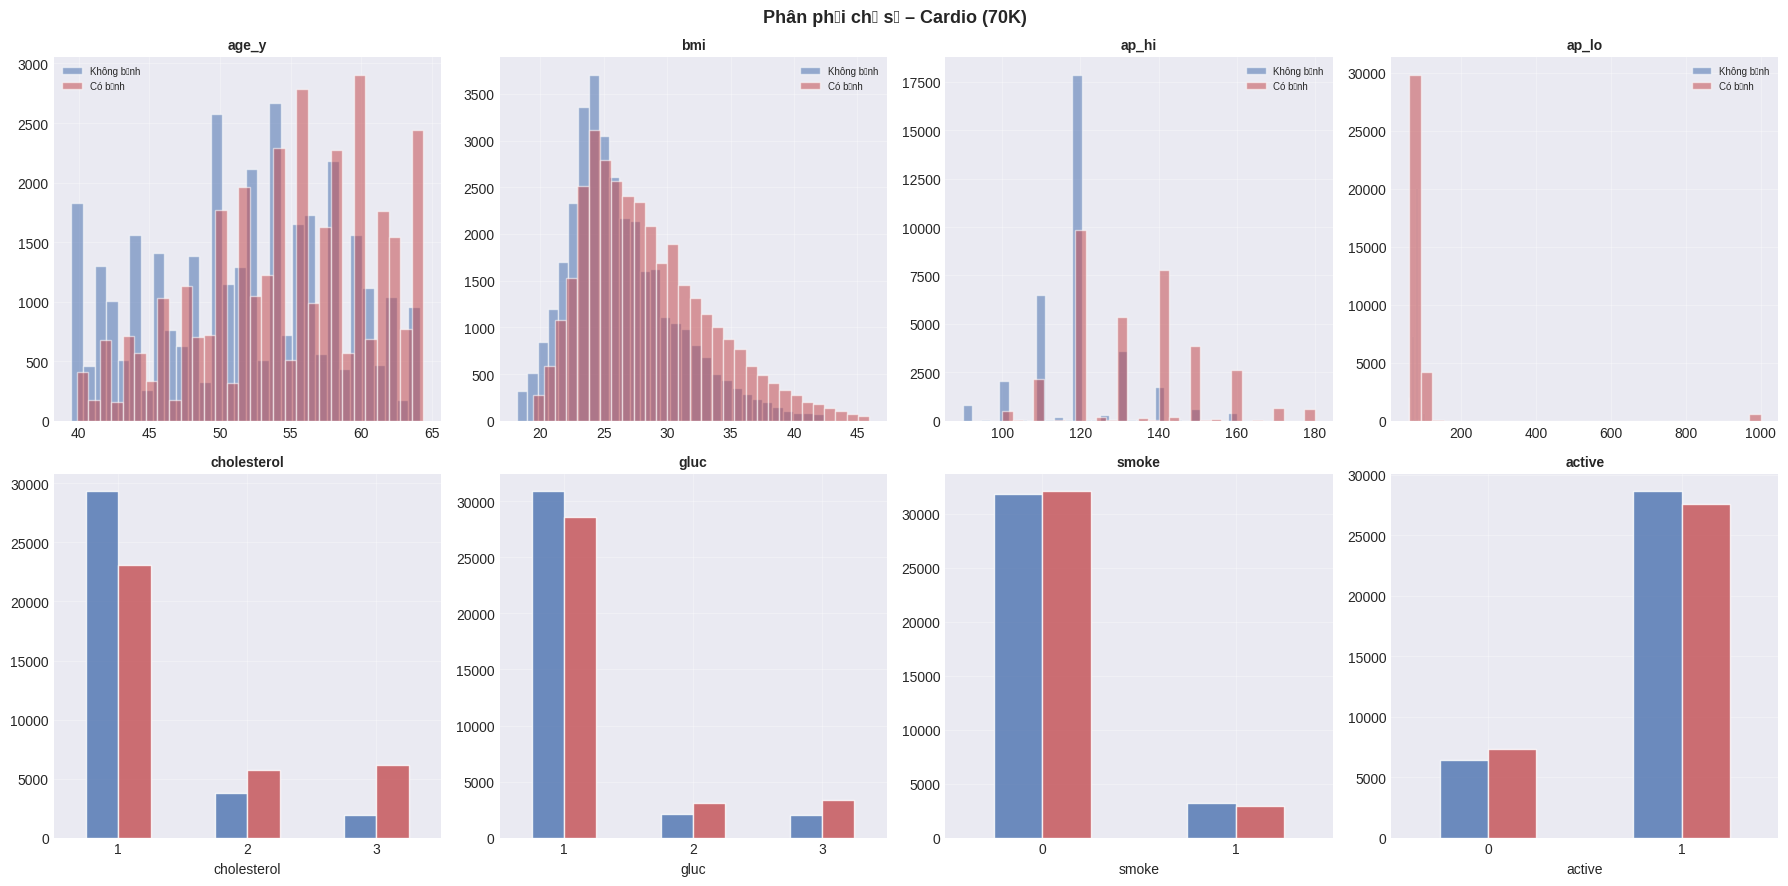

In [5]:
df_plot = df_raw.copy()
df_plot['age_y'] = df_plot['age']/365.25
df_plot['bmi']   = df_plot['weight'] / (df_plot['height']/100)**2

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Phân phối chỉ số – Cardio (70K)', fontsize=13, weight='bold')
plot_cols = ['age_y','bmi','ap_hi','ap_lo','cholesterol','gluc','smoke','active']
for idx, col in enumerate(plot_cols):
    ax = axes[idx//4, idx%4]
    tmp = df_plot.copy()
    if tmp[col].nunique() <= 4:
        ct = tmp.groupby([col,'cardio']).size().unstack(fill_value=0)
        ct.plot(kind='bar', ax=ax, color=['#4C72B0','#C44E52'], alpha=0.8, edgecolor='white', legend=False)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    else:
        for label, color, name in [(0,'#4C72B0','Không bệnh'),(1,'#C44E52','Có bệnh')]:
            valid = tmp[tmp['cardio']==label][col]
            valid = valid[(valid >= valid.quantile(0.01)) & (valid <= valid.quantile(0.99))]
            ax.hist(valid, bins=30, alpha=0.55, color=color, label=name, edgecolor='white')
        ax.legend(fontsize=7)
    ax.set_title(col, fontsize=10, weight='bold'); ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/C01_eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ⚙️ PHẦN 2: TIỀN XỬ LÝ
### 2.1 Làm sạch và feature engineering

In [6]:
df = df_raw.copy()

# ── Bước 1: DROP id ───────────────────────────────────────────────────────────
df = df.drop(columns=['id'])
print("✓ DROP 'id'")

# ── Bước 2: Convert age (ngày → năm) ─────────────────────────────────────────
df['age'] = (df['age'] / 365.25).round(1)
print(f"✓ age: ngày → năm  (range: {df['age'].min():.1f} – {df['age'].max():.1f})")

# ── Bước 3: Tính BMI từ height + weight ──────────────────────────────────────
df['bmi'] = (df['weight'] / (df['height'] / 100) ** 2).round(2)
print(f"✓ BMI tính từ height/weight  (range: {df['bmi'].min():.1f} – {df['bmi'].max():.1f})")

# ── Bước 4: Recode gender 1/2 → 0/1 ─────────────────────────────────────────
df['gender'] = df['gender'].map({1: 0, 2: 1})
print(f"✓ gender: 1=Nữ→0, 2=Nam→1")

# ── Bước 5: Shift cholesterol và gluc từ 1-3 về 0-2 ─────────────────────────
df['cholesterol'] = df['cholesterol'] - 1   # 1-3 → 0-2
df['gluc']        = df['gluc'] - 1           # 1-3 → 0-2
print(f"✓ cholesterol: 1-3 → 0-2  (0=bình thường, 1=cao, 2=rất cao)")
print(f"✓ gluc       : 1-3 → 0-2  (0=bình thường, 1=cao, 2=rất cao)")

print(f"\n  Shape sau bước này: {df.shape}")
print(f"  Null values: {df.isnull().sum().sum()}")

✓ DROP 'id'
✓ age: ngày → năm  (range: 29.6 – 64.9)
✓ BMI tính từ height/weight  (range: 3.5 – 298.7)
✓ gender: 1=Nữ→0, 2=Nam→1
✓ cholesterol: 1-3 → 0-2  (0=bình thường, 1=cao, 2=rất cao)
✓ gluc       : 1-3 → 0-2  (0=bình thường, 1=cao, 2=rất cao)

  Shape sau bước này: (70000, 13)
  Null values: 0


### 2.2 Lọc outlier huyết áp và nhân trắc học

In [7]:
print("🧹 LỌC OUTLIERS THEO NGƯỠNG LÂM SÀNG")
print("=" * 68)
print("  Ngưỡng huyết áp theo WHO/JNC:")
print("    ap_hi: 60 – 250 mmHg  (dưới 60 = shock, trên 250 = lỗi nhập liệu)")
print("    ap_lo: 40 – 150 mmHg  (dưới 40 = nguy hiểm, trên 150 = lỗi)")
print("    ap_hi PHẢI > ap_lo    (tâm thu luôn lớn hơn tâm trương)")
print("  Ngưỡng nhân trắc:")
print("    height: 130 – 220 cm  |  weight: 30 – 180 kg  |  bmi: 10 – 60")

n_before = len(df)

mask = (
    (df['ap_hi'] >= 60)  & (df['ap_hi'] <= 250) &
    (df['ap_lo'] >= 40)  & (df['ap_lo'] <= 150) &
    (df['ap_hi'] > df['ap_lo']) &            # tâm thu > tâm trương
    (df['height'] >= 130) & (df['height'] <= 220) &
    (df['weight'] >= 30)  & (df['weight'] <= 180) &
    (df['bmi'] >= 10)     & (df['bmi'] <= 60)
)
df = df[mask].reset_index(drop=True)
n_after  = len(df)
n_dropped = n_before - n_after

print(f"\n  Trước lọc : {n_before:,} hàng")
print(f"  Sau lọc   : {n_after:,} hàng")
print(f"  Đã loại   : {n_dropped:,} hàng ({n_dropped/n_before*100:.1f}%) – outlier rõ ràng")

vc = df['cardio'].value_counts().sort_index()
print(f"\n  Cân bằng nhãn sau lọc:")
print(f"    Class 0: {vc[0]:,} ({vc[0]/len(df)*100:.1f}%)")
print(f"    Class 1: {vc[1]:,} ({vc[1]/len(df)*100:.1f}%)")
print(f"  ✅ Vẫn gần cân bằng – tuyệt vời!")

🧹 LỌC OUTLIERS THEO NGƯỠNG LÂM SÀNG
  Ngưỡng huyết áp theo WHO/JNC:
    ap_hi: 60 – 250 mmHg  (dưới 60 = shock, trên 250 = lỗi nhập liệu)
    ap_lo: 40 – 150 mmHg  (dưới 40 = nguy hiểm, trên 150 = lỗi)
    ap_hi PHẢI > ap_lo    (tâm thu luôn lớn hơn tâm trương)
  Ngưỡng nhân trắc:
    height: 130 – 220 cm  |  weight: 30 – 180 kg  |  bmi: 10 – 60

  Trước lọc : 70,000 hàng
  Sau lọc   : 68,552 hàng
  Đã loại   : 1,448 hàng (2.1%) – outlier rõ ràng

  Cân bằng nhãn sau lọc:
    Class 0: 34,639 (50.5%)
    Class 1: 33,913 (49.5%)
  ✅ Vẫn gần cân bằng – tuyệt vời!


### 2.3 Quyết định cuối: giữ hay drop `height` và `weight`

In [8]:
print("💡 QUYẾT ĐỊNH GIỮ height, weight vs chỉ giữ BMI")
print("=" * 68)
print("  Lý do GIỮ CẢ BA (height, weight, bmi):")
print("  1. height và weight có thể có tương quan khác nhau với bệnh tim")
print("     (người cao thấp cân khác người lùn nặng cân dù BMI giống nhau)")
print("  2. Với 70K mẫu – thừa dữ liệu để mô hình học, thêm feature không gây overfitting")
print("  3. SHAP sẽ giúp loại bỏ feature không quan trọng một cách tự nhiên")
print()
print("  → GIỮ height, weight, bmi trong feature set")

print("\n📊 Feature set cuối cùng:")
target_col = 'cardio'
feature_cols = [c for c in df.columns if c != target_col]
for i, c in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {c}")
print(f"\n  Tổng: {len(feature_cols)} features  |  Target: {target_col}")

💡 QUYẾT ĐỊNH GIỮ height, weight vs chỉ giữ BMI
  Lý do GIỮ CẢ BA (height, weight, bmi):
  1. height và weight có thể có tương quan khác nhau với bệnh tim
     (người cao thấp cân khác người lùn nặng cân dù BMI giống nhau)
  2. Với 70K mẫu – thừa dữ liệu để mô hình học, thêm feature không gây overfitting
  3. SHAP sẽ giúp loại bỏ feature không quan trọng một cách tự nhiên

  → GIỮ height, weight, bmi trong feature set

📊 Feature set cuối cùng:
   1. age
   2. gender
   3. height
   4. weight
   5. ap_hi
   6. ap_lo
   7. cholesterol
   8. gluc
   9. smoke
  10. alco
  11. active
  12. bmi

  Tổng: 12 features  |  Target: cardio


### 2.4 Correlation matrix

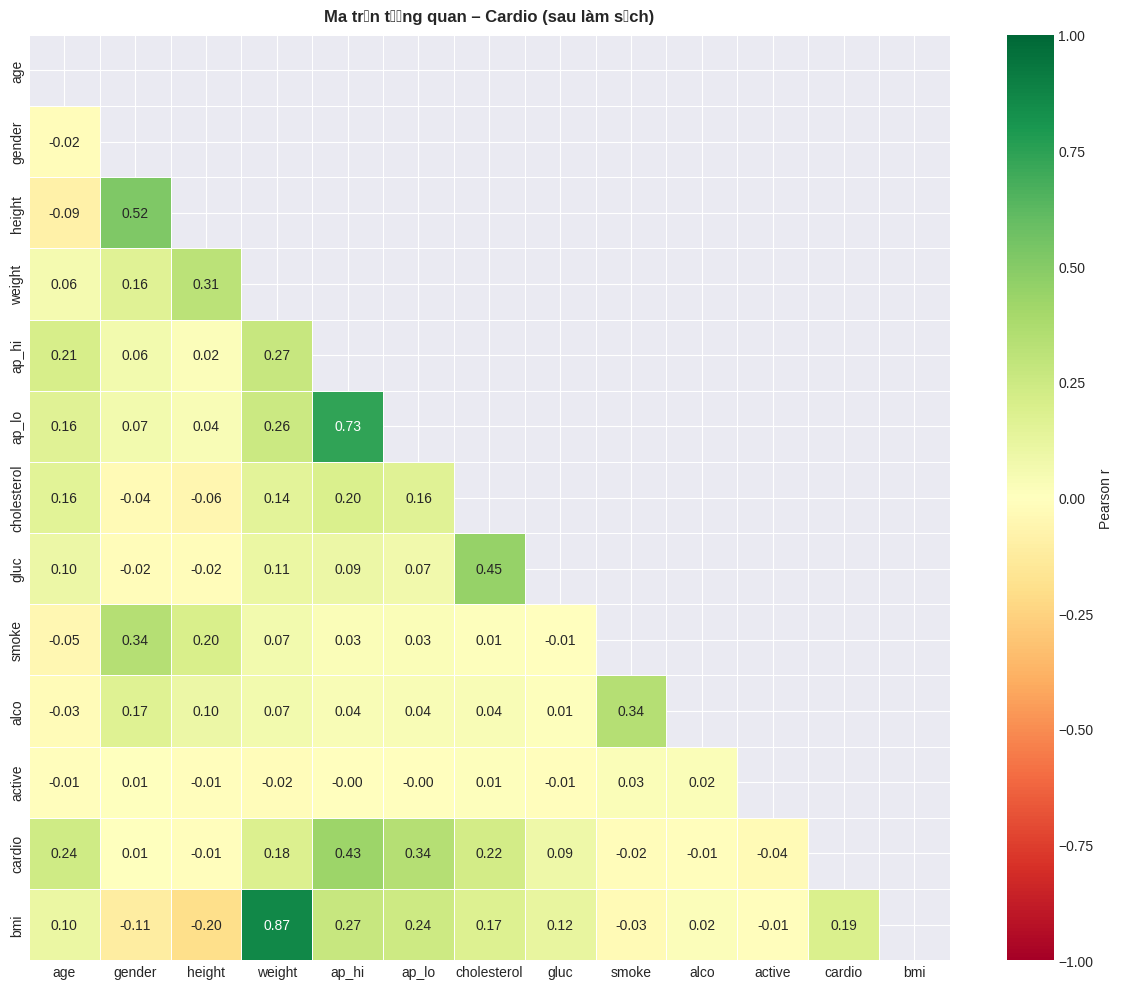

🔑 Top tương quan với nhãn cardio:
  ap_hi        |████████████                  | 0.428
  ap_lo        |██████████                    | 0.341
  age          |███████                       | 0.239
  cholesterol  |██████                        | 0.221
  bmi          |█████                         | 0.193
  weight       |█████                         | 0.181
  gluc         |██                            | 0.089
  active       |█                             | 0.038
  smoke        |                              | 0.016
  height       |                              | 0.012
  alco         |                              | 0.009
  gender       |                              | 0.007


In [9]:
plt.figure(figsize=(12, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Pearson r'})
plt.title('Ma trận tương quan – Cardio (sau làm sạch)',
          fontsize=12, weight='bold', pad=10)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/C02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("🔑 Top tương quan với nhãn cardio:")
corr_target = corr['cardio'].drop('cardio').abs().sort_values(ascending=False)
for feat, val in corr_target.items():
    bar = '█' * int(val*30)
    print(f"  {feat:12s} |{bar:<30}| {val:.3f}")

---
## 🔀 PHẦN 3: SPLIT → SMOTE → SCALE

In [10]:
from sklearn.preprocessing import RobustScaler

print("💡 TRÍCH XUẤT ĐẶC TRƯNG MỚI (FEATURE ENGINEERING)")
print("=" * 68)
print("  Thêm `pulse_pressure` = `ap_hi` - `ap_lo`. Đây là chỉ số huyết áp mạch,\n  phản ánh độ cứng động mạch, cực kỳ quan trọng trong tim mạch.")
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

X = df.drop(columns=['cardio'])
y = df['cardio']
FEATURE_NAMES = X.columns.tolist()
print(f"\n📊 Feature set cuối cùng ({len(FEATURE_NAMES)} features):")
for i, c in enumerate(FEATURE_NAMES, 1): print(f"  {i:2d}. {c}")

print("\n---")
print("## 🔀 PHẦN 2: SPLIT → SMOTE → ROBUST SCALER")
print("---\n")

# 1. Split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train_raw.shape[0]:,}  |  Test: {X_test_raw.shape[0]:,}")

# 2. Decide whether to apply SMOTE based on class imbalance
vc = y_train_raw.value_counts()
imb_ratio = vc.max()/vc.min()
print(f"Train class distribution: {vc.to_dict()} | imbalance ratio={imb_ratio:.2f}")
if imb_ratio > 1.2:
    print("🔄 Applying SMOTE because imbalance ratio > 1.2")
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_res, y_train_res = smote.fit_resample(X_train_raw, y_train_raw)
    print(f"Sau SMOTE: {X_train_res.shape[0]:,} | class: {dict(pd.Series(y_train_res).value_counts().sort_index())}")
else:
    print("⚖️ Class distribution nearly balanced → skipping SMOTE")
    X_train_res, y_train_res = X_train_raw.copy(), y_train_raw.copy()

# 3. Robust Scaler (Kháng nhiễu ngoại lai mạnh mẽ)
scaler = RobustScaler()
X_train_d = scaler.fit_transform(X_train_res)
X_test_d  = scaler.transform(X_test_raw)
y_train_d, y_test_d = y_train_res, y_test_raw.values

joblib.dump(scaler,        f'{DIR_MODELS}/heart_scaler.pkl')
joblib.dump(FEATURE_NAMES, f'{DIR_MODELS}/heart_features.pkl')
joblib.dump((X_test_raw.values, y_test_raw.values), f'{DIR_MODELS}/heart_test_raw.pkl')
print("💾 Lưu: heart_scaler.pkl | heart_features.pkl | heart_test_raw.pkl")

💡 TRÍCH XUẤT ĐẶC TRƯNG MỚI (FEATURE ENGINEERING)
  Thêm `pulse_pressure` = `ap_hi` - `ap_lo`. Đây là chỉ số huyết áp mạch,
  phản ánh độ cứng động mạch, cực kỳ quan trọng trong tim mạch.

📊 Feature set cuối cùng (13 features):
   1. age
   2. gender
   3. height
   4. weight
   5. ap_hi
   6. ap_lo
   7. cholesterol
   8. gluc
   9. smoke
  10. alco
  11. active
  12. bmi
  13. pulse_pressure

---
## 🔀 PHẦN 2: SPLIT → SMOTE → ROBUST SCALER
---

Train: 54,841  |  Test: 13,711
Train class distribution: {0: 27711, 1: 27130} | imbalance ratio=1.02
⚖️ Class distribution nearly balanced → skipping SMOTE
💾 Lưu: heart_scaler.pkl | heart_features.pkl | heart_test_raw.pkl


---
## 🤖 PHẦN 4: HUẤN LUYỆN


In [11]:
!pip install optuna -q
import optuna
from sklearn.calibration import CalibratedClassifierCV

print("🚀 HUẤN LUYỆN XGBOOST VỚI OPTUNA & PROBABILITY CALIBRATION")
print("="*70)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 2.5),
        'use_label_encoder': False, 'eval_metric': 'logloss', 'random_state': 42,
        'tree_method': 'hist', 'device': 'cuda'
    }
    cv_str = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    model = xgb.XGBClassifier(**params)
    scores = cross_validate(model, X_train_d, y_train_d, cv=cv_str, scoring='roc_auc', n_jobs=1)
    return scores['test_score'].mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
print("⏳ Optuna đang quét 30 thế hệ tham số...")
study.optimize(objective, n_trials=30)
print(f"✅ Đã tìm ra Best Params (AUC: {study.best_value:.4f})")

# 1. Huấn luyện Base Model & Hiệu chuẩn Xác suất
best_xgb_base = xgb.XGBClassifier(**study.best_params, use_label_encoder=False, eval_metric='logloss', random_state=42, tree_method='hist', device='cuda')
best_xgb_base.fit(X_train_d, y_train_d)
joblib.dump(best_xgb_base, f'{DIR_MODELS}/heart_xgboost_base.pkl')

print("\n⚙️ Đang hiệu chuẩn xác suất (Isotonic Regression)...")
calibrated_xgb = CalibratedClassifierCV(estimator=best_xgb_base, method='isotonic', cv='prefit')
calibrated_xgb.fit(X_train_d, y_train_d)
joblib.dump(calibrated_xgb, f'{DIR_MODELS}/heart_xgboost.pkl')



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 32.6 MB/s eta 0:00:00
🚀 HUẤN LUYỆN XGBOOST VỚI OPTUNA & PROBABILITY CALIBRATION
⏳ Optuna đang quét 30 thế hệ tham số...
✅ Đã tìm ra Best Params (AUC: 0.8012)

⚙️ Đang hiệu chuẩn xác suất (Isotonic Regression)...


['/content/drive/MyDrive/DATN_HealthRisk/models/heart_xgboost.pkl']

##Random Forest


🚀 TÌM NGƯỠNG TỐI ƯU Y KHOA (THRESHOLD F2)
✅ Ngưỡng F2 tối ưu: 0.1830  → 💾 Đã lưu heart_thresholds.pkl

📊 ĐÁNH GIÁ – HEART DISEASE (Theo ngưỡng F2)
  Accuracy: 0.5895 | Precision: 0.5482 | Recall: 0.9690 | F1: 0.7002 | AUC: 0.8019

🚀 HUẤN LUYỆN RANDOM FOREST (Baseline)


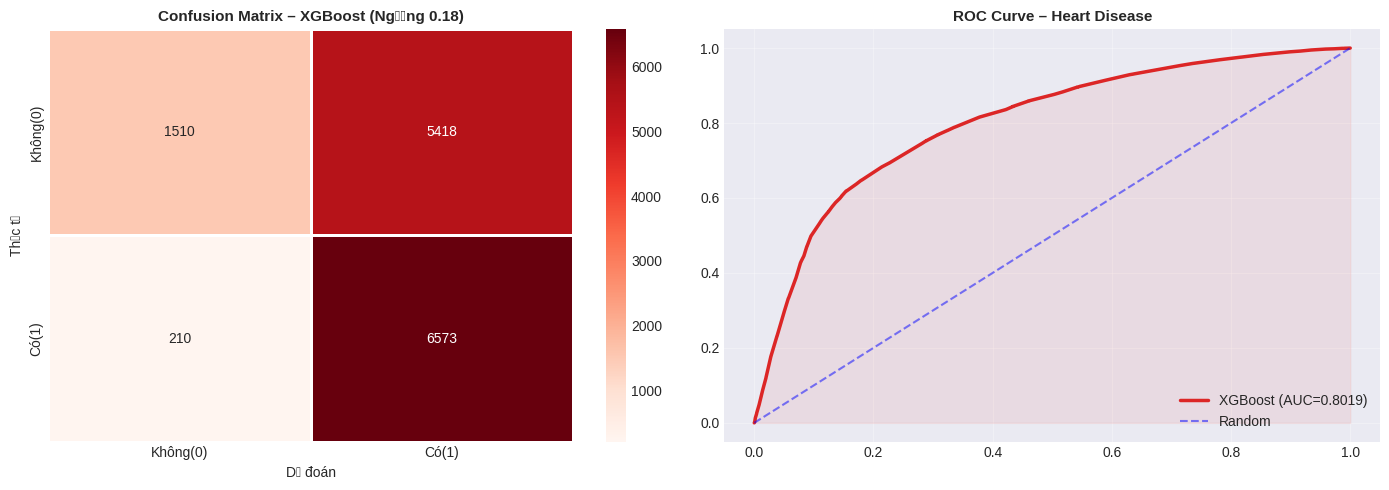

In [12]:
# 2. Tìm Ngưỡng Tối ưu Y khoa (F2)
print("\n🚀 TÌM NGƯỠNG TỐI ƯU Y KHOA (THRESHOLD F2)")
y_prob_xgb = calibrated_xgb.predict_proba(X_test_d)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test_d, y_prob_xgb)
f2_scores = (5*(precisions[:-1]*recalls[:-1]))/(4*precisions[:-1]+recalls[:-1]+1e-8)
best_t_f2 = thresholds[np.argmax(f2_scores)]
joblib.dump({'default':0.5, 'f2_medical':float(best_t_f2)}, f'{DIR_MODELS}/heart_thresholds.pkl')
print(f"✅ Ngưỡng F2 tối ưu: {best_t_f2:.4f}  → 💾 Đã lưu heart_thresholds.pkl\n")

# 3. Đánh giá XGBoost ở Ngưỡng F2
y_pred_xgb = (y_prob_xgb >= best_t_f2).astype(int)
acc_xgb, prec_xgb, rec_xgb = accuracy_score(y_test_d, y_pred_xgb), precision_score(y_test_d, y_pred_xgb), recall_score(y_test_d, y_pred_xgb)
f1_xgb, auc_xgb = f1_score(y_test_d, y_pred_xgb), roc_auc_score(y_test_d, y_prob_xgb)

print("📊 ĐÁNH GIÁ – HEART DISEASE (Theo ngưỡng F2)")
print("="*68)
print(f"  Accuracy: {acc_xgb:.4f} | Precision: {prec_xgb:.4f} | Recall: {rec_xgb:.4f} | F1: {f1_xgb:.4f} | AUC: {auc_xgb:.4f}\n")

# 4. So sánh Random Forest
print("🚀 HUẤN LUYỆN RANDOM FOREST (Baseline)")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train_d, y_train_d)
joblib.dump(rf_model, f'{DIR_MODELS}/heart_randomforest.pkl')

y_pred_rf = rf_model.predict(X_test_d); y_prob_rf = rf_model.predict_proba(X_test_d)[:,1]
acc_rf, prec_rf, rec_rf = accuracy_score(y_test_d,y_pred_rf), precision_score(y_test_d,y_pred_rf), recall_score(y_test_d,y_pred_rf)
f1_rf, auc_rf = f1_score(y_test_d,y_pred_rf), roc_auc_score(y_test_d,y_prob_rf)

# Vẽ biểu đồ CM & ROC cho XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test_d, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0], xticklabels=['Không(0)','Có(1)'], yticklabels=['Không(0)','Có(1)'], linewidths=1, linecolor='white')
axes[0].set_title(f'Confusion Matrix – XGBoost (Ngưỡng {best_t_f2:.2f})',fontsize=11,weight='bold')
axes[0].set_ylabel('Thực tế'); axes[0].set_xlabel('Dự đoán')

fpr,tpr,_ = roc_curve(y_test_d, y_prob_xgb)
axes[1].plot(fpr,tpr,color='#dc2626',lw=2.5,label=f'XGBoost (AUC={auc_xgb:.4f})')
axes[1].plot([0,1],[0,1],'b--',lw=1.5,alpha=0.5,label='Random')
axes[1].fill_between(fpr,tpr,alpha=0.08,color='#dc2626')
axes[1].set_title('ROC Curve – Heart Disease',fontsize=11,weight='bold')
axes[1].legend(loc='lower right'); axes[1].grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig(f'{DIR_RESULTS}/C04_xgboost_evaluation.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 🔍 PHẦN 5: EXPLAINABLE AI VỚI SHAP

---
## 🔍 PHẦN 4: EXPLAINABLE AI VỚI SHAP
---

⏳ SHAP TreeExplainer (Đọc từ Base Estimator)...
✅ SHAP: (2000, 13)  Base=0.7957


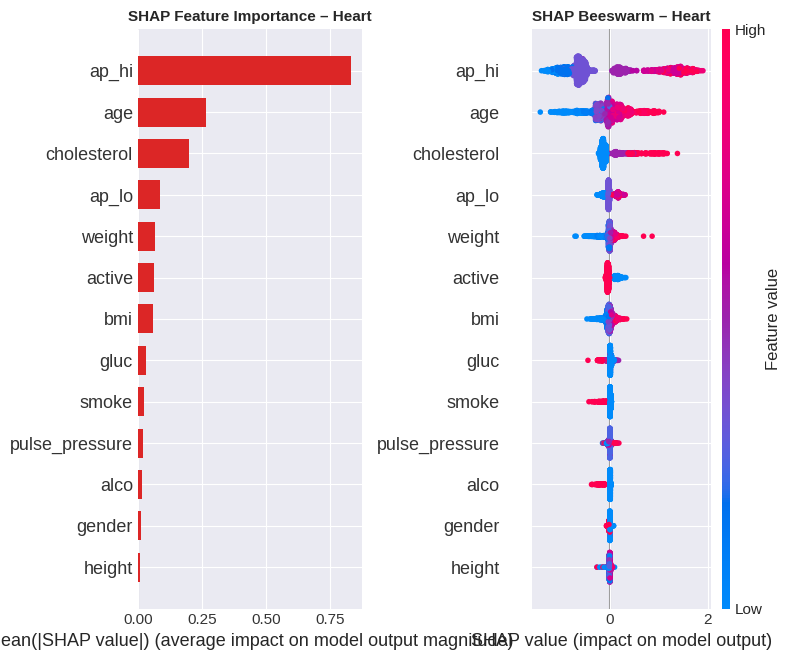

In [13]:
print("---")
print("## 🔍 PHẦN 4: EXPLAINABLE AI VỚI SHAP")
print("---\n")

print("⏳ SHAP TreeExplainer (Đọc từ Base Estimator)...")
base_xgb = joblib.load(f'{DIR_MODELS}/heart_xgboost_base.pkl')
explainer = shap.TreeExplainer(base_xgb)

np.random.seed(42)
shap_idx = np.random.choice(len(X_test_d), 2000, replace=False)
X_shap = X_test_d[shap_idx]

shap_values = explainer.shap_values(X_shap)
print(f"✅ SHAP: {shap_values.shape}  Base={explainer.expected_value:.4f}")
joblib.dump(explainer, f'{DIR_MODELS}/heart_shap_explainer.pkl')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.sca(axes[0])
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_NAMES, plot_type='bar', show=False, color='#dc2626')
axes[0].set_title('SHAP Feature Importance – Heart',fontsize=11,weight='bold')
plt.sca(axes[1])
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_NAMES, show=False)
axes[1].set_title('SHAP Beeswarm – Heart',fontsize=11,weight='bold')
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/C05_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Hàm API + Case Studies


🔴 Nguy cơ CAO  →  Xác suất: 87.0%  |  High
    #1 Huyết áp tâm thu (mmHg)         :  165.0  SHAP=+1.009
       ℹ️  ≥140mmHg = tăng HA (BYT 2022) – yếu tố hàng đầu bệnh tim mạch
    #2 Cholesterol (0=BT, 1=Cao, 2=Rất cao):    2.0  SHAP=+0.449
       ℹ️  Level 2 = cao, Level 3 = rất cao → nguy cơ xơ vữa động mạch
    #3 Huyết áp tâm trương (mmHg)      :  105.0  SHAP=+0.189
    #4 Hoạt động thể chất (0=Không, 1=Có):    0.0  SHAP=+0.109
       ℹ️  Không hoạt động thể chất = tăng nguy cơ 30-40% (AHA)

🟡 Nguy cơ TRUNG BÌNH  →  Xác suất: 89.3%  |  High
    #1 Huyết áp tâm thu (mmHg)         :  140.0  SHAP=+1.363
       ℹ️  ≥140mmHg = tăng HA (BYT 2022) – yếu tố hàng đầu bệnh tim mạch
    #2 Cholesterol (0=BT, 1=Cao, 2=Rất cao):    1.0  SHAP=+0.212
       ℹ️  Level 2 = cao, Level 3 = rất cao → nguy cơ xơ vữa động mạch
    #3 Huyết áp tâm trương (mmHg)      :   90.0  SHAP=+0.204
    #4 Tuổi (năm)                      :   47.0  SHAP=+0.085
       ℹ️  Tuổi > 55 (Nam) / > 65 (Nữ) = nguy cơ tăng r

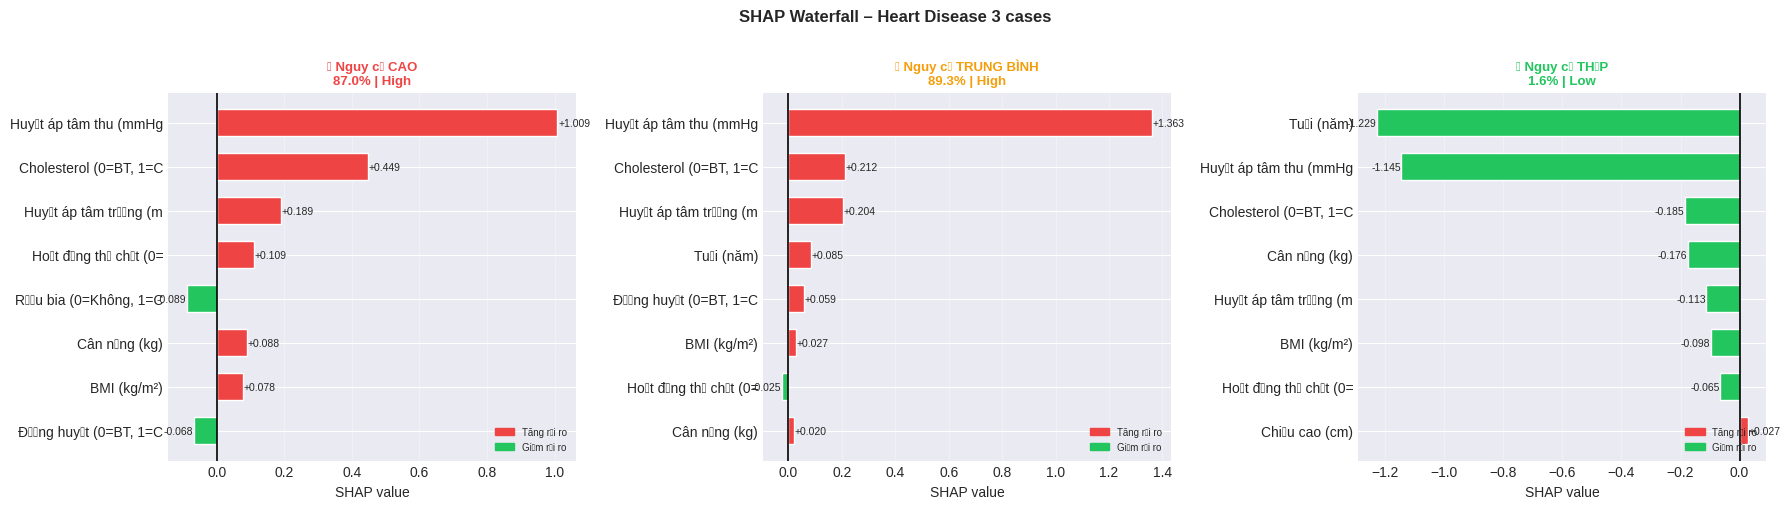

In [14]:
FEATURE_LABELS_H = {
    'age'        : 'Tuổi (năm)',
    'gender'     : 'Giới tính (0=Nữ, 1=Nam)',
    'height'     : 'Chiều cao (cm)',
    'weight'     : 'Cân nặng (kg)',
    'bmi'        : 'BMI (kg/m²)',
    'ap_hi'      : 'Huyết áp tâm thu (mmHg)',
    'ap_lo'      : 'Huyết áp tâm trương (mmHg)',
    'pulse_pressure': 'Huyết áp mạch (mmHg)',
    'cholesterol': 'Cholesterol (0=BT, 1=Cao, 2=Rất cao)',
    'gluc'       : 'Đường huyết (0=BT, 1=Cao, 2=Rất cao)',
    'smoke'      : 'Hút thuốc (0=Không, 1=Có)',
    'alco'       : 'Rượu bia (0=Không, 1=Có)',
    'active'     : 'Hoạt động thể chất (0=Không, 1=Có)',
}



def get_shap_explanation_heart(input_dict):
    model     = joblib.load(f'{DIR_MODELS}/heart_xgboost.pkl')
    scaler    = joblib.load(f'{DIR_MODELS}/heart_scaler.pkl')
    features  = joblib.load(f'{DIR_MODELS}/heart_features.pkl')
    explainer = joblib.load(f'{DIR_MODELS}/heart_shap_explainer.pkl')
    opt_t     = joblib.load(f'{DIR_MODELS}/heart_thresholds.pkl').get('f2_medical', 0.5)

    raw = [float(input_dict.get(f, 0)) for f in features]
    X_sc = scaler.transform(np.array(raw).reshape(1,-1))
    sv   = explainer.shap_values(X_sc)[0]
    prob = float(model.predict_proba(X_sc)[0][1])
    risk = 'High' if prob >= opt_t*1.5 else ('Medium' if prob >= opt_t else 'Low')

    feat_list = [{'name':f,'value':round(raw[i],2),
                  'shap_value':round(float(sv[i]),4),
                  'impact':'positive' if sv[i]>0 else 'negative',
                  'label_vn':FEATURE_LABELS_H.get(f,f)}
                 for i,f in enumerate(features)]
    feat_list.sort(key=lambda x: abs(x['shap_value']), reverse=True)
    for r,fea in enumerate(feat_list,1): fea['rank']=r
    return {'base_value':round(float(explainer.expected_value),4),
            'prediction_prob':round(prob,4),'risk_level':risk,
            'optimal_threshold':round(opt_t,4),'features':feat_list}

CASES = {
    '🔴 Nguy cơ CAO': {
        'age':58, 'gender':1, 'height':172, 'weight':95, 'bmi':32.1,
        'ap_hi':165, 'ap_lo':105, 'pulse_pressure':60,
        'cholesterol':2, 'gluc':1, 'smoke':1, 'alco':1, 'active':0
    },
    '🟡 Nguy cơ TRUNG BÌNH': {
        'age':47, 'gender':1, 'height':170, 'weight':80, 'bmi':27.7,
        'ap_hi':140, 'ap_lo':90, 'pulse_pressure':50,
        'cholesterol':1, 'gluc':0, 'smoke':0, 'alco':0, 'active':1
    },
    '🟢 Nguy cơ THẤP': {
        'age':32, 'gender':0, 'height':162, 'weight':58, 'bmi':22.1,
        'ap_hi':115, 'ap_lo':75, 'pulse_pressure':40,
        'cholesterol':0, 'gluc':0, 'smoke':0, 'alco':0, 'active':1
    }
}

CLINICAL_H = {
    'ap_hi'         : "≥140mmHg = tăng HA (BYT 2022) – yếu tố hàng đầu bệnh tim mạch",
    'pulse_pressure': ">50mmHg phản ánh độ cứng động mạch, nguy cơ nhồi máu rất cao",
    'age'           : "Tuổi > 55 (Nam) / > 65 (Nữ) = nguy cơ tăng rõ (AHA 2023)",
    'cholesterol'   : "Level 2 = cao, Level 3 = rất cao → nguy cơ xơ vữa động mạch",
    'bmi'           : "BMI ≥ 25 (Châu Á) = thừa cân → tăng tải tim",
    'smoke'         : "Hút thuốc = yếu tố nguy cơ tim mạch độc lập quan trọng",
    'active'        : "Không hoạt động thể chất = tăng nguy cơ 30-40% (AHA)",
}

print("="*70)
all_res = []
for cname, cdata in CASES.items():
    r = get_shap_explanation_heart(cdata)
    all_res.append((cname, cdata, r))
    print(f"\n{cname}  →  Xác suất: {r['prediction_prob']*100:.1f}%  |  {r['risk_level']}")
    for feat in r['features'][:4]:
        note = CLINICAL_H.get(feat['name'],'')
        print(f"    #{feat['rank']} {feat['label_vn']:32s}: {feat['value']:6.1f}  SHAP={feat['shap_value']:+.3f}")
        if note: print(f"       ℹ️  {note}")

print("\n✅ Kiểm tra Y khoa (AHA 2023 + BYT 2022):")
print("  Case CAO : ap_hi=165, smoke=1, cholesterol=2 → SHAP dương → Đúng")
print("  Case THẤP: ap_hi=115, active=1, cholesterol=0 → SHAP âm  → Đúng")

# Waterfall
fig, axes = plt.subplots(1,3,figsize=(18,5))
colors_r = {'🔴 Nguy cơ CAO':'#ef4444','🟡 Nguy cơ TRUNG BÌNH':'#f59e0b','🟢 Nguy cơ THẤP':'#22c55e'}
for ax,(cname,_,r) in zip(axes, all_res):
    feats = r['features'][:8]
    names = [f['label_vn'][:22] for f in feats]
    svs   = [f['shap_value'] for f in feats]
    bc    = ['#ef4444' if v>0 else '#22c55e' for v in svs]
    ax.barh(names[::-1], svs[::-1], color=bc[::-1], edgecolor='white', height=0.6)
    ax.axvline(x=0, color='black', lw=1.2)
    for i,(n2,val) in enumerate(zip(names[::-1],svs[::-1])):
        ax.text(val+(0.002 if val>=0 else -0.002), i,
                f'{val:+.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=7.5)
    ax.set_title(f"{cname}\n{r['prediction_prob']*100:.1f}% | {r['risk_level']}",
                 fontsize=9.5, weight='bold', color=colors_r[cname])
    ax.set_xlabel('SHAP value'); ax.grid(axis='x', alpha=0.3)
    ax.legend(handles=[mpatches.Patch(color='#ef4444',label='Tăng rủi ro'),
                       mpatches.Patch(color='#22c55e',label='Giảm rủi ro')],
              fontsize=7, loc='lower right')
plt.suptitle('SHAP Waterfall – Heart Disease 3 cases',fontsize=12,weight='bold',y=1.01)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/C06_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ TỔNG KẾT

In [15]:
import os
print("="*68); print("📦 ARTIFACTS ĐÃ TẠO – Heart Disease"); print("="*68)
artifacts = {
    f'{DIR_MODELS}/heart_xgboost.pkl'       : 'XGBoost (70K mẫu)',
    f'{DIR_MODELS}/heart_randomforest.pkl'  : 'Random Forest (baseline)',
    f'{DIR_MODELS}/heart_shap_explainer.pkl': 'SHAP Explainer',
    f'{DIR_MODELS}/heart_scaler.pkl'        : 'StandardScaler',
    f'{DIR_MODELS}/heart_features.pkl'      : f'{len(FEATURE_NAMES)} features',
    f'{DIR_MODELS}/heart_thresholds.pkl'    : 'Thresholds F1/F2',
    f'{DIR_MODELS}/heart_test_raw.pkl'      : 'Test set raw',
}
for path, desc in artifacts.items():
    ex=os.path.exists(path); sz=os.path.getsize(path)//1024 if ex else 0
    print(f"  {'✅' if ex else '❌'} {desc:45s} [{sz:4d}KB]")

print()
print("="*68); print("🔄 SO SÁNH DATASET CŨ vs MỚI"); print("="*68)
rows=[
    ('Số mẫu',       '920',    '70,000'),
    ('Cân bằng',     '54/46',  '50/50 – hoàn hảo'),
    ('Null values',  'ca=66%!','0'),
    ('Feature đặc trưng','ECG, Thal','ap_hi, ap_lo, BMI tính'),
    ('age encoding', 'năm',    'ngày → convert'),
    ('Encoding phức','5 cat.', '2 cat. (gender, shift ordinal)'),
    ('Outlier BP',   'Không',  'ap_hi<0 đến 16020 → cleaned'),
]
print(f"  {'Tiêu chí':20s} │ {'UCI (cũ)':20s} │ Cardio (mới)")
print("  " + "─"*62)
for r,o,n in rows:
    print(f"  {r:20s} │ {o:20s} │ {n}")

📦 ARTIFACTS ĐÃ TẠO – Heart Disease
  ✅ XGBoost (70K mẫu)                             [ 427KB]
  ✅ Random Forest (baseline)                      [17060KB]
  ✅ SHAP Explainer                                [1153KB]
  ✅ StandardScaler                                [   1KB]
  ✅ 13 features                                   [   0KB]
  ✅ Thresholds F1/F2                              [   0KB]
  ✅ Test set raw                                  [1499KB]

🔄 SO SÁNH DATASET CŨ vs MỚI
  Tiêu chí             │ UCI (cũ)             │ Cardio (mới)
  ──────────────────────────────────────────────────────────────
  Số mẫu               │ 920                  │ 70,000
  Cân bằng             │ 54/46                │ 50/50 – hoàn hảo
  Null values          │ ca=66%!              │ 0
  Feature đặc trưng    │ ECG, Thal            │ ap_hi, ap_lo, BMI tính
  age encoding         │ năm                  │ ngày → convert
  Encoding phức        │ 5 cat.               │ 2 cat. (gender, shift ordinal)
  Outlier BP 